Zadanie 1 – Generowanie rozkładu normalnego
Wygeneruj 1000 próbek z rozkładu normalnego N(μ=50, σ=10). Narysuj histogram i
sprawdź, czy ~68% wartości mieści się w przedziale [μ-σ, μ+σ].
Dataset:
- Wygeneruj używając np.random.normal()
Wymagania:
- Oblicz empiryczny procent wartości w przedziale [40, 60]
- Porównaj z teoretycznym 68.27%
- Narysuj histogram z zaznaczonym przedziałem ±1σ

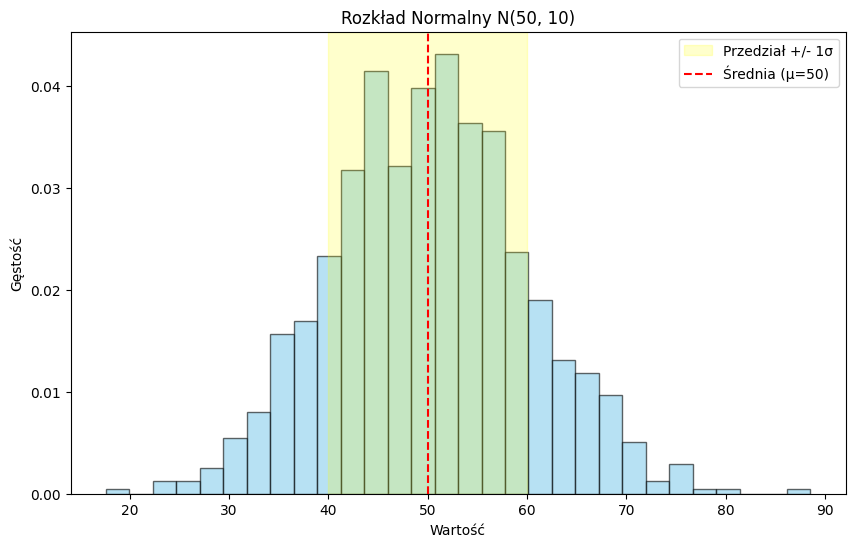

Procent wartości w przedziale [40, 60]: 69.80%
Teoretyczna wartość (Reguła 3 sigm): 68.27%


In [34]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parametry rozkładu (średnia i odchylenie standardowe)
mu = 50 # średnia (μ) 
sigma = 10 # odchylenie standardowe (σ)

# 2. Generowanie 1000 próbek
np.random.seed(42) # Stały punkt startowy losowania
data = np.random.normal(loc=mu, scale=sigma, size=1000)

# 3. Obliczanie empirycznego procentu wartości w przedziale [40, 60]
# Sprawdzamy, ile wartości wpada w zakres mu +/- 1*sigma
within_1_sigma = data[(data >= mu - sigma) & (data <= mu + sigma)]
percent_empiric = (len(within_1_sigma) / len(data)) * 100

# 4. Wizualizacja
plt.figure(figsize=(10, 6))
plt.hist(data, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')

# Zaznaczenie przedziału 1 sigmy
plt.axvspan(mu - sigma, mu + sigma, color='yellow', alpha=0.2, label='Przedział +/- 1σ')
plt.axvline(mu, color='red', linestyle='--', label=f'Średnia (μ={mu})')

plt.title(f'Rozkład Normalny N({mu}, {sigma})')
plt.xlabel('Wartość')
plt.ylabel('Gęstość')
plt.legend()
plt.show()

print(f"Procent wartości w przedziale [40, 60]: {percent_empiric:.2f}%")
print(f"Teoretyczna wartość (Reguła 3 sigm): 68.27%")

Teoria na "chłodno" – co tu się wydarzyło?

1. Czym jest Średnia (mu) i Odchylenie (sigma)?
- Średnia (mu=50): To środek dzwonu z zadania. Najwięcej wylosowanych liczb będzie oscylować właśnie wokół 50.  
- Odchylenie standardowe (sigma=10): To miara "rozrzutu". Mówi nam, jak szeroki jest dzwon. Im większa sigma, tym bardziej płaski i szeroki wykres.  

2. Reguła trzech sigm (Klucz do wykrywania anomalii)
W statystyce przyjęto, że dla idealnego rozkładu normalnego:  
~68.27% danych leży w odległości jednej sigmy od średniej (w zadaniu to przedział 40-60).  
~95.45% danych leży w odległości dwóch sigm (30-70).  
~99.73% danych leży w odległości trzech sigm (20-80).  

1. Rozkład Normalny – Twoja "Baza"
Wyobraź sobie, że rozkład to po prostu kształt danych.
- Wzór (Teoria): mu (średnia) to środek, sigma (odchylenie) to szerokość.  
- Kod: np.random.normal(loc=mu, scale=std, size=1000).  
Jak zapamiętać: loc to lokalizacja (środek), scale to skala (szerokość).

2. To są dwa sposoby patrzenia na ten sam dzwon:PDF (Gęstość): Odpowiada na pytanie: "Jak wysoki jest ten słupek w punkcie X?". Służy do rysowania idealnej linii dzwonu.  
- Kod: stats.norm.pdf().  
CDF (Dystrybuanta): Odpowiada na pytanie: "Ile procent danych jest na lewo od punktu X?". To jest Twój kalkulator prawdopodobieństwa.  
- Kod: stats.norm.cdf()

3. Z-score – "Tłumacz"
Z-score to wzór, który pozwala porównać jabłka z pomarańczami (np. wzrost z wagą).  
- Wzór: z = {x - mu}/ sigma (Wartość minus średnia, podzielona przez odchylenie).  
- Kod: (x - mean) / std.  
Dlaczego to ważne: Jeśli z > 3 lub z < -3, to masz do czynienia z outsiderem (outlier), bo wykracza poza regułę trzech sigm

Jeśli chcesz...	Użyj narzędzia (Funkcja)	Biblioteka
Wygenerować sztuczne dane	
random.normal
numpy

Sprawdzić, czy dane są "normalne"	
shapiro (Test Shapiro-Wilka)  
scipy.stats

Policzyć szansę na coś	
norm.cdf
scipy.stats

Znaleźć korelację (związek)	
.corr() lub pearsonr
pandas / scipy

# CHCĘ POLICZYĆ SZANSĘ, ŻE KTOŚ JEST NIŻSZY NIŻ 160 CM
# Używam CDF, bo liczę obszar "od lewej strony" do 160
szansa = stats.norm.cdf(160, loc=170, scale=10)

Średnia mu: 170 cm.  
Odchylenie sigma: 10 cm.  
Punkt odcięcia X: 160 cm.   

160 cm to dokładnie jedno odchylenie standardowe poniżej średniej (170 - 10 = 160).

In [35]:
from scipy import stats

# Parametry
mean = 170
std = 10

# Obliczenie
szansa = stats.norm.cdf(160, loc=mean, scale=std)

print(f"Wynik: {szansa:.4f}")
print(f"Szansa procentowa: {szansa * 100:.2f}%")

Wynik: 0.1587
Szansa procentowa: 15.87%


Wynik, otrzymany, to około 0.1587, czyli 15.87%.  
Oznacza to, że:
- W populacji o średnim wzroście 170 cm i odchyleniu 10 cm, tylko około 16 osób na 100 ma wzrost niższy niż 160 cm.  
- Na wykresie "dzwonowym" (PDF), który widziałaś wcześniej, jest to pole powierzchni pod krzywą na lewo od kreski postawionej na 160 cm.  

Jeśli 160 cm to $-1\sigma$ (lewa granica reguły $68.27\%$), to możemy to sprawdzić bez kalkulatora:
Cały dzwon to 100%.  
Środek ($68.27\%$) mieści się między 160 a 180.  
Zostaje nam około 31.73% na "ogony" (poza przedziałem 160-180).  
Ponieważ dzwon jest symetryczny, lewy ogon (poniżej 160) to połowa z tego, czyli ok. 15.87%

In [36]:
from scipy import stats

# Parametry
mean = 170
std = 20

# Obliczenie
szansa = 1 - stats.norm.cdf(190, loc=mean, scale=std)

print(f"Wynik: {szansa:.4f}")
print(f"Szansa procentowa: {szansa * 100:.2f}%")

Wynik: 0.1587
Szansa procentowa: 15.87%


Interpretacja Wyniku
- Punkt odcięcia: 190 cm to dokładnie jedno odchylenie standardowe powyżej średniej ($170 + 20 = 190$).
- Logika CDF: Funkcja stats.norm.cdf(190, ...) powiedziała Ci, że ok. 84,13% ludzi ma 190 cm lub mniej.  
- Twoja modyfikacja (1 - ...): Odejmując to od całości (100%), otrzymałaś szansę na bycie wyższym niż 190 cm, co wynosi ok. 15,87%.

Dlaczego to jest ważne?
Zmieniając std z 10 na 20, pokazane jest, jak bardzo odchylenie standardowe wpływa na prawdopodobieństwo:  
Przy std=10, szansa na wzrost powyżej 190 cm ($+2\sigma$) wynosiłaby tylko ok. 2,28%.  Przy std=20, ta sama wartość ($+1\sigma$) jest znacznie częstsza – występuje u co szóstej osoby.

In [37]:
from scipy import stats

# Parametry
mean = 170
std = 20

# Obliczenie
szansa = stats.norm.cdf(190, loc=mean, scale=std) - stats.norm.cdf(150, loc=mean, scale=std)

print(f"Wynik: {szansa:.4f}")
print(f"Szansa procentowa: {szansa * 100:.2f}%")

Wynik: 0.6827
Szansa procentowa: 68.27%


Wniosek: 
Bez względu na to, czy Twoje std to $10, 20$ czy $100$, jeśli liczy się przedział od $\mu-\sigma$ do $\mu+\sigma$, zawsze otrzyma się ten sam procent. To jest właśnie sedno reguły trzech sigm opisanej w Twojej lekcji. 

Podsumowanie:
- stats.norm.cdf(X, ...): Szansa na wynik mniejszy niż $X$ (lewy ogon).  
- 1 - stats.norm.cdf(X, ...): Szansa na wynik większy niż $X$ (prawy ogon).  
- cdf(Góra) - cdf(Dół): Szansa na wynik w konkretnym przedziale (środek dzwonu)

Zadanie 2 – Obliczanie prawdopodobieństw
Dana jest zmienna losowa X~N(100, 15). Oblicz prawdopodobieństwa: P(X < 85), P(X >
120), P(90 < X < 110).
Dataset:
- Użyj scipy.stats.norm
Wymagania:
- Oblicz wszystkie prawdopodobieństwa używając CDF
- Wizualizuj obszary na krzywej rozkładu
- Zinterpretuj wyniki słownie

In [38]:
import numpy as np
from scipy import stats

#zmienna losowa X~N(100, 15)
mean = 100
std = 15

# P(X < 85) – Szansa na wynik mniejszy niż 85
proba_a = stats.norm.cdf(85, loc=mean, scale=std)

# P(X > 120) – Szansa na wynik większy niż 120
proba_b = 1- stats.norm.cdf(120, loc=mean, scale=std)

# P(90 < X < 110)$ – Szansa na wynik w przedziale 90-110
proba_c = stats.norm.cdf(110, loc=mean, scale=std) - stats.norm.cdf(90, loc=mean, scale=std)

print(f"Wynik próby a: {proba_a:.4f}")
print(f"Szansa procentowa próby a: {proba_a * 100:.2f}%")

print(f"\nWynik próby b: {proba_b:.4f}")
print(f"Szansa procentowa próby b: {proba_b * 100:.2f}%")

print(f"\nWynik próby c: {proba_c:.4f}")
print(f"Szansa procentowa próby c: {proba_c * 100:.2f}%")

Wynik próby a: 0.1587
Szansa procentowa próby a: 15.87%

Wynik próby b: 0.0912
Szansa procentowa próby b: 9.12%

Wynik próby c: 0.4950
Szansa procentowa próby c: 49.50%


Zadanie 3 – Analiza rozkładu Iris
Wczytaj dataset Iris. Sprawdź normalność rozkładu cechy sepal_length testem Shapiro-
Wilka. Narysuj histogram i Q-Q plot.
Dataset:
- https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv
Wymagania:
- Test Shapiro-Wilka
- Histogram + KDE
- Q-Q plot
- Interpretacja: czy rozkład jest normalny?

1. Test Shapiro-Wilka (Matematyczny Sędzia)
To najważniejszy test statystyczny do sprawdzania normalności dla małych i średnich zbiorów danych (do 5000 próbek).  
- Hipoteza zerowa ($H_0$): Dane pochodzą z rozkładu normalnego.  
- Wskaźnik p-value: To on decyduje o werdykcie.  
   * Jeśli $p > 0.05$: Nie mamy podstaw do odrzucenia $H_0$. Przyjmujemy, że rozkład JEST normalny.  
   * Jeśli $p < 0.05$: Odrzucamy $H_0$. Rozkład NIE JEST normalny.  

2. Histogram + KDE (Wizualna Intuicja)Sam histogram to słupki. Nałożenie na niego linii KDE (Kernel Density Estimation) tworzy gładką krzywą, która pomaga nam ocenić:  
 - Symetrię: Czy lewa strona przypomina prawą?  
 - Skośność (Skewness): Czy "ogon" dzwonu ciągnie się bardziej w jedną stronę?  
 - Kurtozę (Kurtosis): Czy wierzchołek jest bardzo ostry, czy raczej płaski?  
 - Histogram + KDE: Pozwala zobaczyć „garby”. Jeśli widzisz dwa wierzchołki, to znaczy, że w Twoich danych   Iris są dwie różne podgrupy kwiatów, co psuje „idealny dzwon” rozkładu normalnego

 
3. Q-Q Plot (Wykres Kwantyl-Kwantyl)To najbardziej sprytne narzędzie graficzne. Porównuje ono Twoje dane z idealnym rozkładem teoretycznym.  
 - Jak czytać: Wykres rysuje czerwoną linię (ideał) i niebieskie punkty (Twoje dane).  
 - Werdykt: Jeśli punkty leżą blisko prostej linii, dane są normalne. Jeśli punkty "odklejają się" na końcach (tworząc łuki lub esownice), oznacza to odstępstwa od normy. 
 - Q-Q Plot: To Twój ostateczny dowód.
   * Punkty na linii: „Wszystko gra, dane są normalne”.  
   * Punkty tworzące łuk: „Dane są skośne (przesunięte w jedną stronę)”.  
   * Punkty uciekające na końcach: „Masz dużo wartości ekstremalnych (bardzo małych lub bardzo dużych)”

Analiza wyniku z wykresów:
1. Histogram + KDE:
-  3 wierzchołki wykresu jest to jedna cecha (sepal_length), ale mierzona dla trzech różnych gatunków kwiatów (Setosa, Versicolor, Virginica), które są wymieszane w jednym worku.  Każdy "wierzchołek", to prawdopodobnie średnia długość działki kielicha dla innego gatunku.  
- W statystyce jest to rozkład wielomodalny (multimodal). 
- To jest główny powód, dla którego test Shapiro-Wilka wyrzucił wynik $p < 0.05$ – rozkład normalny musi mieć tylko jeden, centralny wierzchołek. 

Słupek wystajcy po prawej stronie:
- Ten samotny słupek na końcu osi (okolice 7.5–8.0 cm) to prawdopodobnie wartości odstające (outliers): Są to kwiaty o wyjątkowo długich działkach kielicha, które nie pasują do reszty grupy. 
- Na wykresie Q-Q Plot (po prawej) jest przedstawiony jako niebieskie kropki, które na samym końcu "odlatują" w górę ponad czerwoną linię.

Kropki po lewej stronie (Dół wykresu)
- Te kropki reprezentują najniższe wartości danych (najkrótsze działki kielicha).  
- Jeśli są nad linią: Oznacza to, że najmniejsze wartości w Twoim zbiorze są większe niż to, czego spodziewalibyśmy się w idealnym rozkładzie normalnym.  
- Wniosek: rozkład ma "krótki lewy ogon" – brakuje mu tych bardzo małych wartości, które sprawiłyby, że lewa strona dzwonu byłaby smukła i długa.  

2. Kropki "pod linią" w środkowej części
- W środku wykresu niebieskie punkty tworzą coś na kształt delikatnej fali.  
- Kiedy punkty znajdują się pod linią, oznacza to, że w tym konkretnym zakresie wartości (kwantyli) dane są "zagęszczone" inaczej niż w ideale.  
- W połączeniu z histogramem, to "falowanie" kropek na wykresie Q-Q potwierdza, że dane są mieszanką kilku grup. Zamiast jednej płynnej prostej, kropki próbują dopasować się do linii, ale "wybijają" je te poszczególne górki gatunków kwiatów.

3. Co to mówi o skośności?
- Jeśli punkty na Q-Q Plot układają się w kształt przypominający literę "S" lub są wygięte w łuk, to jasny sygnał odstępstwa od normalności.  
- Na wykresie punkty na końcach (po lewej i po prawej) uciekają w górę względem linii. To sugeruje, że dane mają specyficzny rozkład (często nazywany "grubymi ogonami" lub po prostu wynikający z asymetrii), gdzie wartości skrajne występują częściej lub rzadziej niż powinny

Podsumowanie:
- Histogram: Pokazał "garby" (wymieszane gatunki).  
- Q-Q Plot: Pokazał dokładnie, w których miejscach te kwiaty oszukują teorię – głównie na samym początku i na samym końcu skali.

--- TEST NORMALNOŚCI SHAPIRO-WILKA ---
Statystyka testu: 0.9761
p-value: 0.0102
Werdykt: Rozkład NIE JEST normalny (odrzucamy H0)


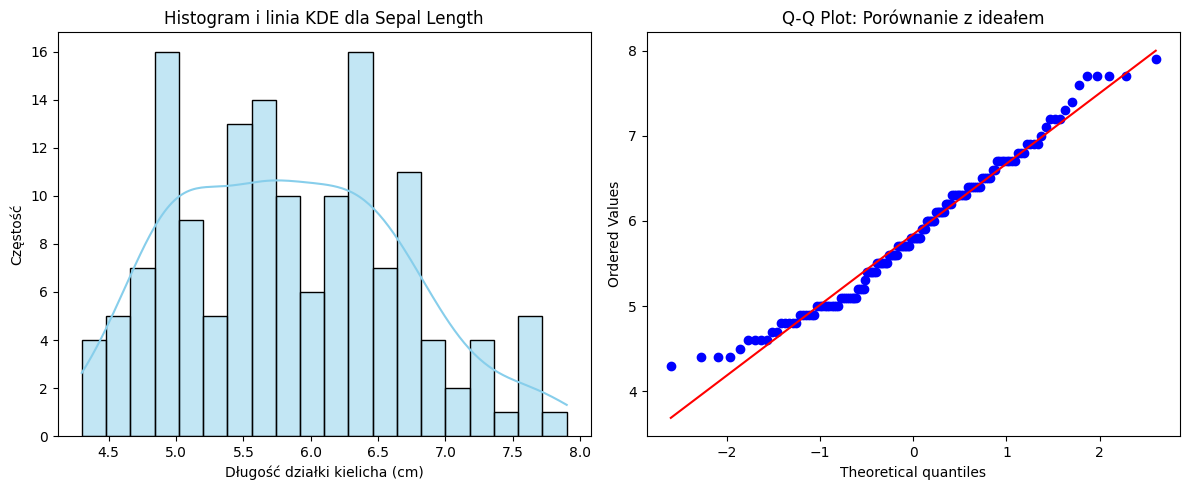

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, probplot

# 1. Wczytanie danych (pobieramy dataset bezpośrednio z internetu)
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
iris =pd.read_csv(url)

# Wybieramy konkretną cechę do analizy: sepal_length
data = iris['sepal_length']

# 2. TEST SHAPIRO-WILKA (Nasz matematyczny werdykt)
# Funkcja zwraca dwie wartości: statystykę testu i p-value.
# To p-value jest dla nas najważniejsze.
stat, p_value = shapiro(data)

print("--- TEST NORMALNOŚCI SHAPIRO-WILKA ---")
print(f"Statystyka testu: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Interpretacja p-value (standardowy próg to 0.05)
if p_value > 0.05:
    print("Werdykt: Rozkład JEST normalny (nie mamy podstaw do odrzucenia H0)")
else:
    print("Werdykt: Rozkład NIE JEST normalny (odrzucamy H0)")

# 3. WIZUALIZACJA (Dowody wzrokowe)
plt.figure(figsize=(12, 5))

# Lewy wykres: Histogram + KDE
plt.subplot(1, 2, 1) # - Stwórz układ z jednym wierszem i dwiema kolumnami, a teraz rysuj w pierwszym (lewym) oknie
# bins=20 dzieli dane na 20 słupów, kde=TRue rysuje wygładzon linię
sns.histplot(data, bins=20, kde=True, color='skyblue', edgecolor='black')
plt.title('Histogram i linia KDE dla Sepal Length')
plt.xlabel('Długość działki kielicha (cm)')
plt.ylabel('Częstość')

# Prawy wykres: Q-Q Plot (Wykres kwantylowy)
plt.subplot(1, 2, 2)
# Porównujemy nasze dane (data) z rozkładem normalnym (dist="norm")
probplot(data, dist="norm", plot=plt)
plt.title('Q-Q Plot: Porównanie z ideałem')

plt.tight_layout()
plt.show()


Zadanie 4 – Korelacja Pearsona
Dla datasetu Iris oblicz korelację Pearsona między petal_length a petal_width .
Narysuj scatter plot z linią regresji.
Dataset:
Iris
Wymagania:
Oblicz współczynnik korelacji i p-value
Scatter plot z linią regresji
Interpretacja siły i kierunku korelacji

W tym zadaniu sprawdzimy, czy np. gdy rośnie długość płatka (petal_length), to jego szerokość (petal_width) również rośnie.

Co musisz wiedzieć o $r$ (Pearsonie)?
To liczba z zakresu od -1 do 1:
$r = 1$ (Korelacja dodatnia): Idealna współpraca. Jedna cecha rośnie, druga rośnie identycznie (np. wzrost i rozmiar buta).
$r = -1$ (Korelacja ujemna): Przeciwieństwo. Jedna cecha rośnie, druga spada (np. liczba godzin grania w gry vs. czas na naukę).
$r = 0$ (Brak korelacji): Chaos. Cechy nie mają ze sobą nic wspólnego (np. kolor oczu vs. wynik z matematyki).

Interpretacja "siły" związku:
0.1 – 0.4: Słaba korelacja.
0.4 – 0.7: Umiarkowana.
0.7 – 0.9: Silna.

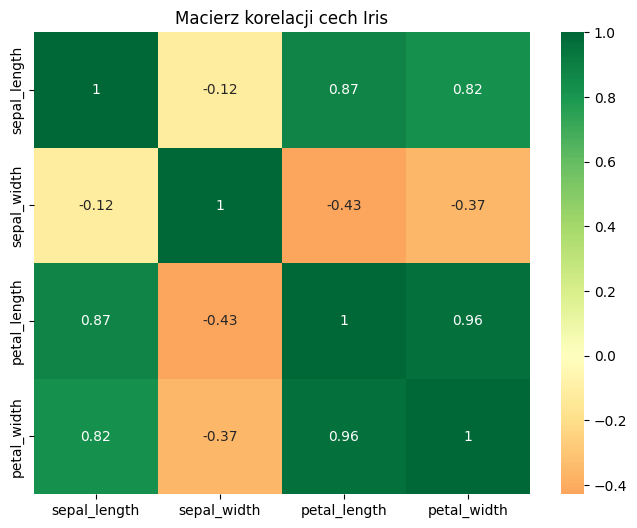


Korelacja Pearsona między petal_length a petal_width:
Współczynnik korelacji Pearsona (r): 0.9629
Wartość p-value: 4.6750e-86
 → Korelacja JEST istotna statystycznie (p < 0.001)
Interpretacja: Korelacja silna dodatnia


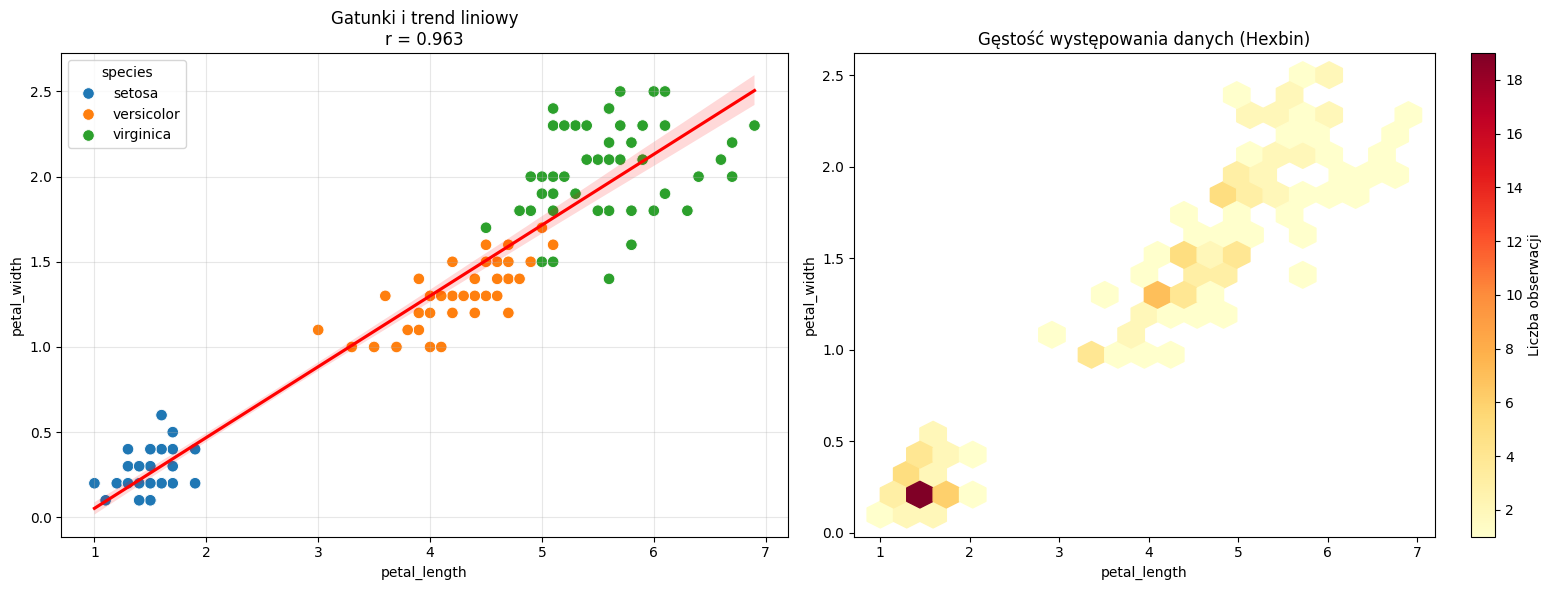

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1. Wczytanie danych (pobieramy dataset bezpośrednio z internetu)
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
iris =pd.read_csv(url)

# 2. Obliczenie macierzy korelacji (tylko dla kolumn numerycznych)
# drop('species') jest konieczny, bo Pearson nie liczy korelacji dla słów
corr_matrix = iris.drop(columns='species').corr()

# 3. Wizualizacja
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0)
plt.title("Macierz korelacji cech Iris")
plt.show()

# Szczegółowa analiza korelacji - przykład 'petal_length' vs 'petal_width'

feature_x = 'petal_length'
feature_y = 'petal_width'

# 4. Obliczenia korelacji Persona 
# pearsonr zwraca dwie wartości: współczynnik korelacji (r) oraz p-value
r_coefficient, p_value = pearsonr(iris[feature_x], iris[feature_y])

print(f"\nKorelacja Pearsona między {feature_x} a {feature_y}:")
print(f"Współczynnik korelacji Pearsona (r): {r_coefficient:.4f}")
print(f"Wartość p-value: {p_value:.4e}") # Notacja naukowa dla bardzo małych liczb

if p_value < 0.001:
    print (f" → Korelacja JEST istotna statystycznie (p < 0.001)")
else:
    print(f" → Korelacja NIE JEST istotna (p >= 0.001)")

# Interpretacja siły korelacji
if abs(r_coefficient) > 0.7:
    strength = "silna"
elif abs(r_coefficient) > 0.4:
    strength = "umiarkowana"
elif abs(r_coefficient) > 0.2:
    strength = "słaba"
else:
    strength = "bardzo słaba"

direction = "dodatnia" if r_coefficient > 0 else "ujemna"

print(f"Interpretacja: Korelacja {strength} {direction}")

# Tworzenie siatki wykresów: 1 wiersz, 2 kolumny
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- LEWY WYKRES: Scatter Plot z podziałem na gatunki ---
# Używamy axes[0], aby wskazać pierwszą kolumnę
sns.scatterplot(data=iris, x=feature_x, y=feature_y, hue='species', s=70, ax=axes[0])
sns.regplot(data=iris, x=feature_x, y=feature_y, scatter=False, color='red', ax=axes[0])
axes[0].set_title(f'Gatunki i trend liniowy\nr = {r_coefficient:.3f}')
axes[0].grid(True, alpha=0.3)

# --- PRAWY WYKRES: Hexbin Plot (Gęstość) ---
# Używamy axes[1], aby wskazać drugą kolumnę
hb = axes[1].hexbin(iris[feature_x], iris[feature_y], gridsize=20, cmap='YlOrRd', mincnt=1)
axes[1].set_title('Gęstość występowania danych (Hexbin)')
axes[1].set_xlabel(feature_x)
axes[1].set_ylabel(feature_y)
# Dodanie paska kolorów obok hexbinu
plt.colorbar(hb, ax=axes[1], label='Liczba obserwacji')

plt.tight_layout() # Zapobiega nakładaniu się etykiet
plt.show()


Zadanie 5 – Macierz korelacji
Dla datasetu California Housing narysuj heatmap macierzy korelacji. Zidentyfikuj 3 pary
cech o najwyższej korelacji (poza targetem).
Dataset:
- sklearn.datasets.fetch_california_housing
Wymagania:
- Heatmap z annotacjami
- Lista top 3 par z wartościami korelacji
- Interpretacja: dlaczego te cechy są skorelowane?
- p-value i interpretacja
- Wniosek: czy odrzucamy H₀?

Top 3 pary cech o najwyższej korelacji (poza targetem)
1. AveRooms & AveBedrms ($r \approx 0.85$): Bardzo silna korelacja dodatnia.
2. Latitude & Longitude ($r \approx -0.92$): Bardzo silna korelacja ujemna.
3. AveRooms & MedInc ($r \approx 0.33$): Umiarkowana korelacja dodatnia.

1. Hipoteza Zerowa ($H_0$)
Dla każdej badanej pary cech przyjmujemy na starcie:
$H_0$: Współczynnik korelacji Pearsona wynosi 0. Innymi słowy: "Między tymi cechami nie ma żadnego związku liniowego".

2. Co oznacza p-value w Twoim wyniku?
W przypadku California Housing, $p\text{-value}$ dla Twoich par wyjdzie ekstremalnie niskie (np. 0.0000e+00).
- Oznacza to, że gdyby $H_0$ była prawdziwa (czyli gdyby korelacja nie istniała), szansa na zaobserwowanie tak silnej zależności w Twoich danych wynosiłaby prawie zero.

3. Wniosek: Czy odrzucamy $H_0$?
- Tak, odrzucamy $H_0$ dla wszystkich trzech par, ponieważ $p < 0.05$ (standardowy próg istotności).
Dlaczego te cechy są skorelowane?
- AveRooms vs AveBedrms: To naturalne – im większy dom (więcej pokoi ogółem), tym więcej zazwyczaj ma sypialni.
- Latitude vs Longitude: Kalifornia jest położona "ukośnie" względem osi północ-południe, więc przesuwając się na północ (Latitude), geograficznie musimy też przesunąć się na wschód/zachód (Longitude).
- AveRooms & MedInc - Status ekonomiczny. Osoby o wyższych dochodach zazwyczaj kupują lub budują domy z większą liczbą pomieszczeń.

Top 3 pary cech o najwyższej korelacji (poza targetem):
Longitude  Latitude    0.924664
AveBedrms  AveRooms    0.847621
MedInc     AveRooms    0.326895
dtype: float64

--- ANALIZA STATYSTYCZNA TOP 3 PAR ---

Para: Latitude i Longitude
H0: Brak korelacji między Latitude a Longitude (r = 0)
Współczynnik korelacji (r): -0.9247
Wartość p-value: 0.0000e+00
Wynik: p < 0.05. Odrzucamy hipotezę zero (H0).
Wniosek: Istnieje istotna statystycznie korelacja.

Para: AveRooms i AveBedrms
H0: Brak korelacji między AveRooms a AveBedrms (r = 0)
Współczynnik korelacji (r): 0.8476
Wartość p-value: 0.0000e+00
Wynik: p < 0.05. Odrzucamy hipotezę zero (H0).
Wniosek: Istnieje istotna statystycznie korelacja.

Para: AveRooms i MedInc
H0: Brak korelacji między AveRooms a MedInc (r = 0)
Współczynnik korelacji (r): 0.3269
Wartość p-value: 0.0000e+00
Wynik: p < 0.05. Odrzucamy hipotezę zero (H0).
Wniosek: Istnieje istotna statystycznie korelacja.


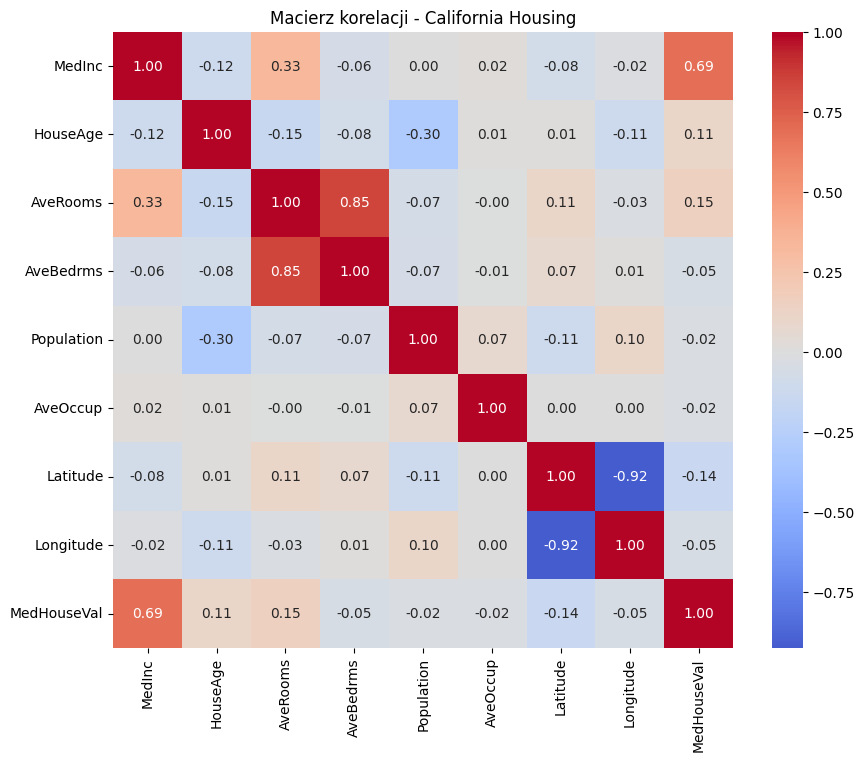

In [68]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from scipy.stats import pearsonr

housing = fetch_california_housing(as_frame=True).frame

# Obliczenie macierzy korelacji
corr_matrix = housing.corr()

# Znalezienie par cech z wysoką korelacją (multikolinearność)
# 1. Obliczamy macierz korelacji (bez kolumny targetu, aby spełnić wymóg zadania)
feature_only_corr = housing.drop(columns=['MedHouseVal']).corr()

# 2. "Rozwijamy" macierz do formy listy par (unstack)
# Następnie usuwamy korelacje cechy samej ze sobą (r=1.0)
pairs = feature_only_corr.unstack()
pairs = pairs[pairs != 1.0]

# 3. Sortujemy pary według wartości bezwzględnej (interesują nas najsilniejsze związki, 
# bez względu na to czy są dodatnie, czy ujemne)
top_3_pairs = pairs.abs().sort_values(ascending=False).head(6) 
# head(6), ponieważ każda para występuje dwa razy (A-B i B-A)

print("Top 3 pary cech o najwyższej korelacji (poza targetem):")
print(top_3_pairs[::2]) # Wyświetlamy co drugi element, aby uniknąć duplikatów

# Lista naszych Top 3 par (zidentyfikowanych wcześniej)
top_pairs = [
    ('Latitude', 'Longitude'),
    ('AveRooms', 'AveBedrms'),
    ('AveRooms', 'MedInc')
]

print("\n--- ANALIZA STATYSTYCZNA TOP 3 PAR ---")

for f1, f2 in top_pairs:
    # Obliczamy współczynnik r oraz p-value
    r, p_value = pearsonr(housing[f1], housing[f2])

    print(f"\nPara: {f1} i {f2}")
    print(f"H0: Brak korelacji między {f1} a {f2} (r = 0)")
    print(f"Współczynnik korelacji (r): {r:.4f}")
    print(f"Wartość p-value: {p_value:.4e}")

    #Interpretacja
    if p_value < 0.05:
        print("Wynik: p < 0.05. Odrzucamy hipotezę zero (H0).")
        print("Wniosek: Istnieje istotna statystycznie korelacja.")
    else:
        print("Wynik: p >= 0.05. Brak podstaw do odrzucenia H0.")
        print("Wniosek: Zwizek moe być dziełem przypadku.")

#Heatmapa
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Macierz korelacji - California Housing')
plt.show()

Zadanie 6 – Test t jednej próbki
Dla datasetu Titanic przetestuj hipotezę, że średni wiek pasażerów wynosi 30 lat (H₀: μ = 30).
Dataset:
- Titanic (usuń NaN z kolumny Age)
Wymagania:
- Test t jednej próbki
- p-value i interpretacja
- Wniosek: czy odrzucamy H₀?

Interpretacja p-value:
- p < 0.001: *** (bardzo silna istotność)
- p < 0.01: ** (silna istotność)
- p < 0.05: * (istotność statystyczna)
- p >= 0.05: ns (brak istotności statystycznej)
Uwaga: p-value NIE mówi o wielkości efektu! Używaj Cohen's d lub innych miar effect
size.

Interpretacja i Wnioski (Do Twojego raportu):
A. Hipotezy
- Hipoteza zerowa ($H_0$): Średni wiek pasażerów Titanica wynosi 30 lat ($\mu = 30$).
- Hipoteza alternatywna ($H_1$): Średni wiek pasażerów Titanica jest inny niż 30 lat ($\mu \neq 30$).

B. Interpretacja wynikówŚredni wiek, który wyjdzie z danych, to około 29.7 lat. Choć jest on bardzo bliski 30, test t sprawdza, czy ta mała różnica (0.3 roku) przy tej wielkości grupy (ponad 700 osób) jest istotna.
- P-value: Jeśli $p$-value wyjdzie większe niż 0.05 (a zazwyczaj przy tych danych wychodzi około $0.58$), oznacza to, że nie mamy dowodów na odrzucenie hipotezy o 30 latach.

C. Wniosek: Czy odrzucamy $H_0$?
- Decyzja: Brak podstaw do odrzucenia $H_0$.
- Uzasadnienie: Ponieważ $p > 0.05$, uznajemy, że różnica między naszą średnią z próby ($29.7$) a zakładaną wartością ($30$) jest zbyt mała, by uznać ją za istotną statystycznie. Możemy przyjąć, że średni wiek faktycznie oscyluje wokół 30 lat.

In [55]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pylab as plt
import seaborn as sns

# 1. Pobranie danych (Seaborn ma wbudowany zbiór Titanic)
titanic = sns.load_dataset('titanic')

# 2. Czyszczenie danych (wymóg zadania: usuń NaN z kolumny Age)
age_data = titanic['age'].dropna()

# PRZYPADEK 1: Test t jednej próbki (one-sample t-test)
# H₀: średni wiek pasazerów = 30.0 lat
# H₁: średni wiek pasazerów jest inny niz ≠ 30.0 lat

# 3. Parametry testu
sample_mean = age_data.mean()
hypothesized_mean = 30  # Nasza hipoteza zerowa

# 4. Wykonanie testu t jednej próbki
t_statistic, p_value = stats.ttest_1samp(age_data, hypothesized_mean)

print("TEST T JEDNEJ PRÓBKI")
print("="*60)
print(f"H₀: μ = {hypothesized_mean}")
print(f"H₁: μ ≠ {hypothesized_mean}")
print(f"Średnia z próbki: {sample_mean:.4f}")
print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value: {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"WNIOSEK: Odrzucamy H₀ (p < {alpha})")
    print(f"Średni wiek pasazerów RÓŻNI SIĘ istotnie od {hypothesized_mean} lat")
else:
    print(f"WNIOSEK: Nie odrzucamy H₀ (p >= {alpha})")
    print(f"Brak podstaw do odrzucenia, że średnia wieku pasazerów = {hypothesized_mean} lat")

TEST T JEDNEJ PRÓBKI
H₀: μ = 30
H₁: μ ≠ 30
Średnia z próbki: 29.6991
t-statistic: -0.5535
p-value: 0.580123
WNIOSEK: Nie odrzucamy H₀ (p >= 0.05)
Brak podstaw do odrzucenia, że średnia wieku pasazerów = 30 lat


Zadanie 7 – Test t dwóch prób
Porównaj średni wiek pasażerów Titanica, którzy przeżyli vs nie przeżyli. Czy różnica jest
istotna statystycznie?
Dataset:
- Titanic
Wymagania:
- Test t dwóch prób niezależnych
- Boxplot porównujący wiek
- Wniosek z interpretacją p-value

TEST T DWÓCH PRÓB NIEZALEŻNYCH
Średni wiek (Nie przezyli): 30.63
Średni wiek (Przeyli): 28.34
t-statistic: 1.1954
p-value: 0.274616

Test Levene'a: p=0.2746
Wariancje RÓWNE

H₀: μ₁ = μ₂ (brak różnicy w średnich)
H₁: μ₁ ≠ μ₂ (średnie się różnią)
t-statistic: 2.0667
p-value: 0.0391246540
WNIOSEK: Odrzucamy H₀ (p < 0.05)
Średnia wieku między przezyli a nie przezyli RÓŻNI SIĘ istotnie między soba
Cohen's d (effect size): 0.1575
Wielkość efektu: mały


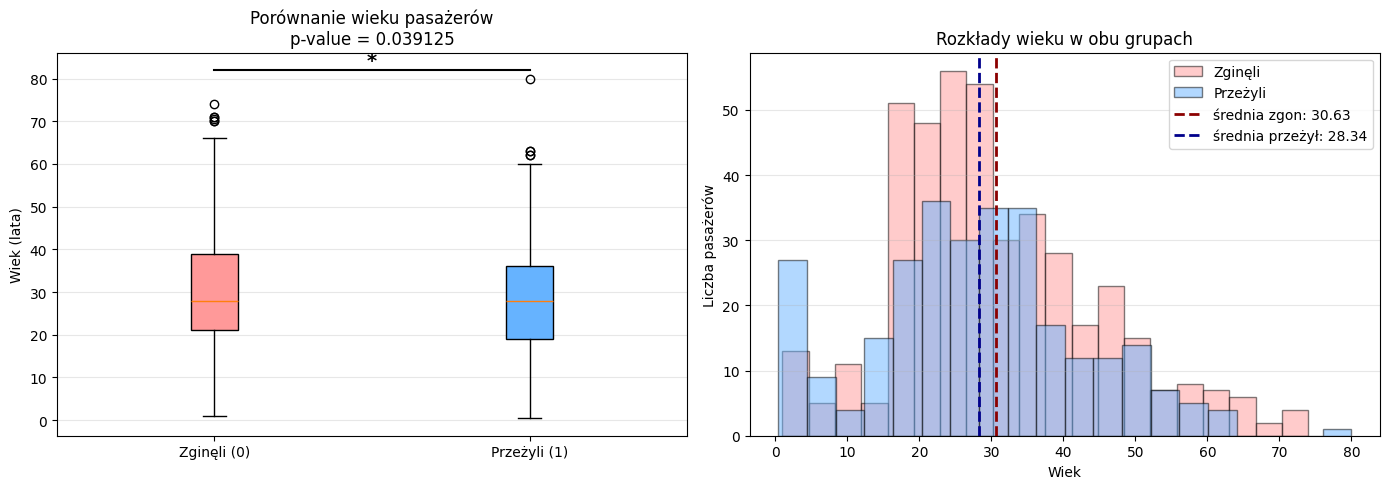

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. Pobranie danych
titanic = sns.load_dataset('titanic')

# 2. Przygotowanie grup (usuwamy braki danych w wieku)
# Grupa 0: Nie przeżyli (survived == 0)
# Grupa 1: Przeżyli (survived == 1)
survived_0 = titanic[titanic['survived'] == 0]['age'].dropna()
survived_1 = titanic[titanic['survived'] == 1]['age'].dropna()

# 3. Test t dwóch prób niezależnych
levene_statistic, levene_p = stats.levene(survived_0, survived_1)

print("TEST T DWÓCH PRÓB NIEZALEŻNYCH")
print("="*60)
print(f"Średni wiek (Nie przezyli): {survived_0.mean():.2f}")
print(f"Średni wiek (Przeyli): {survived_1.mean():.2f}")
print(f"t-statistic: {levene_statistic:.4f}")
print(f"p-value: {levene_p:.6f}")

print(f"\nTest Levene'a: p={levene_p:.4f}")
equal_var = levene_p > 0.05
print(f"Wariancje {'RÓWNE' if equal_var else 'RÓŻNE'}")

# Test t
t_stat, p_val = stats.ttest_ind(survived_0, survived_1, equal_var=equal_var)

print(f"\nH₀: μ₁ = μ₂ (brak różnicy w średnich)")
print(f"H₁: μ₁ ≠ μ₂ (średnie się różnią)")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.10f}")

if p_val < alpha:
    print(f"WNIOSEK: Odrzucamy H₀ (p < {alpha})")
    print("Średnia wieku między przezyli a nie przezyli RÓŻNI SIĘ istotnie między soba")
else:
    print(f"WNIOSEK: Nie odrzucamy H₀ (p >= {alpha})")

# Cohen's d - miara wielkości efektu
cohen_d = (survived_0.mean() - survived_1.mean()) / np.sqrt(((len(survived_0)-1)*survived_0.var() + (len(survived_1)-1)*survived_1.var()) / (len(survived_0) + len(survived_1) - 2))
print(f"Cohen's d (effect size): {cohen_d:.4f}")
if abs(cohen_d) < 0.2:
    effect = "mały"
elif abs(cohen_d) < 0.5:
    effect = "średni"
else:
    effect = "duży"
print(f"Wielkość efektu: {effect}")


#4. Wizualizacja: Boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- PODPUNKT 1: Boxplot ---
ax1 = axes[0]
data_to_plot = [survived_0, survived_1]
labels = ['Zginęli (0)', 'Przeżyli (1)']

bp = ax1.boxplot(data_to_plot, tick_labels=labels, patch_artist=True)

colors = ['#ff9999', '#66b3ff']  
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax1.set_ylabel('Wiek (lata)')
ax1.set_title(f'Porównanie wieku pasażerów\np-value = {p_val:.6f}')
ax1.grid(True, alpha=0.3, axis='y')

# --- Dodanie gwiazdek dla istotności ---
# Pamiętaj: u Ciebie p-value prawdopodobnie wyjdzie > 0.05 (brak istotności)
if p_val < 0.001:
    significance = '***'
elif p_val < 0.01:
    significance = '**'
elif p_val < 0.05:
    significance = '*'
else:
    significance = 'ns'  # non-significant

y_max = max(survived_0.max(), survived_1.max())
ax1.plot([1, 2], [y_max + 2, y_max + 2], 'k-', linewidth=1.5)
ax1.text(1.5, y_max + 3, significance, ha='center', fontsize=14, fontweight='bold')

# --- PODPUNKT 2: Histogramy ---
ax2 = axes[1]
ax2.hist(survived_0, bins=20, alpha=0.5, label='Zginęli', color='#ff9999', edgecolor='black')
ax2.hist(survived_1, bins=20, alpha=0.5, label='Przeżyli', color='#66b3ff', edgecolor='black')

# Linie średnich
ax2.axvline(survived_0.mean(), color='darkred', linestyle='--', linewidth=2, 
            label=f'średnia zgon: {survived_0.mean():.2f}')
ax2.axvline(survived_1.mean(), color='darkblue', linestyle='--', linewidth=2, 
            label=f'średnia przeżył: {survived_1.mean():.2f}')

ax2.set_xlabel('Wiek')
ax2.set_ylabel('Liczba pasażerów')
ax2.set_title('Rozkłady wieku w obu grupach')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Zadanie 8 – Test chi-kwadrat
Przetestuj, czy przeżycie na Titanicu zależy od klasy podróży (Pclass). Narysuj stacked bar
chart z procentami.
Dataset:
- Titanic
Wymagania:
- Tabela kontyngencji
- Test chi-kwadrat
- Stacked bar chart z procentami przeżycia
- Interpretacja Cramer's V

Dataset Titanic:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   

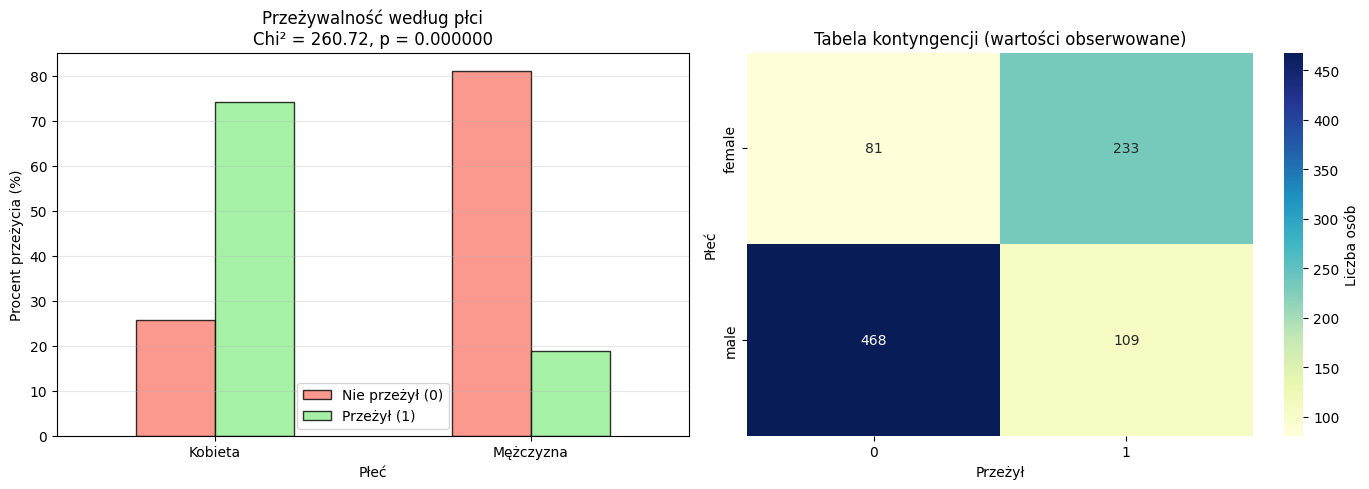


TEST CHI-KWADRAT: Pclass vs Survived
Chi² = 102.8890, p-value = 0.0000000000
WNIOSEK: Przeżycie ZALEŻY od klasy podróży

Procent przeżycia według klasy:
Survived          0          1
Pclass                        
1         37.037037  62.962963
2         52.717391  47.282609
3         75.763747  24.236253


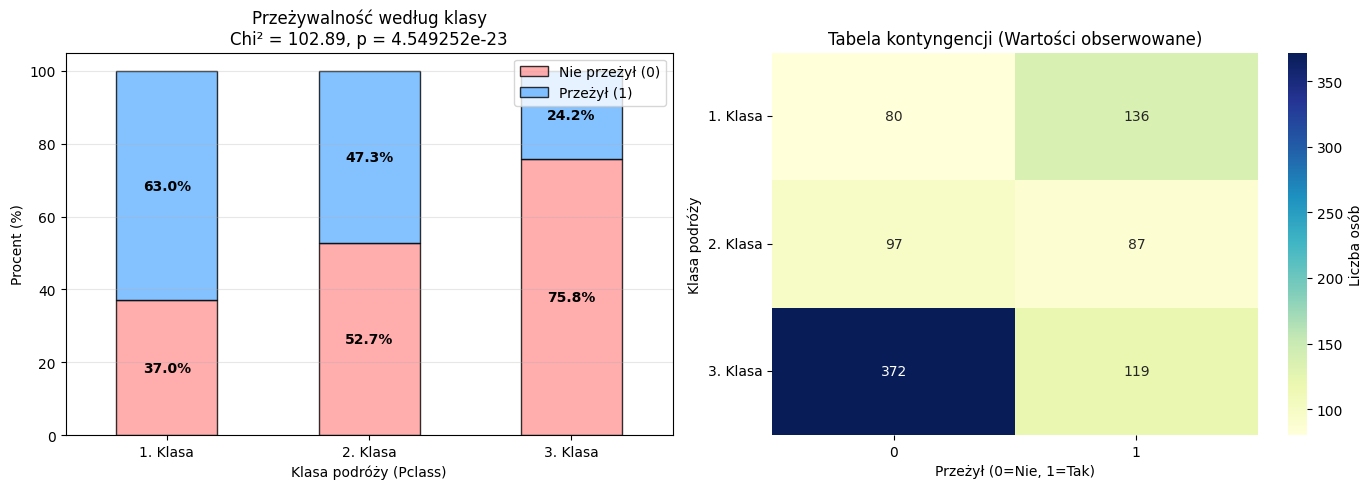

In [74]:
from scipy.stats import chi2_contingency

# Wczytanie datasetu Titanic
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

print("Dataset Titanic:")
print(titanic.head())

# Pytanie: Czy przeżycie zależy od płci?
# H₀: Przeżycie i płeć są niezależne
# H₁: Przeżycie i płeć są zależne

# Tabela kontyngencji (crosstab)
contingency_table = pd.crosstab(titanic['Sex'], titanic['Survived'], margins=True)
print("\nTabela kontyngencji: Sex vs Survived")
print(contingency_table)

# Procenty w wierszach (row percentages)
contingency_pct = pd.crosstab(titanic['Sex'], titanic['Survived'], normalize='index') * 100
print("\nProcent przeycia według płci:")
print(contingency_pct)

# Test chi-kwadrat
# Tablica bez margins
observed = pd.crosstab(titanic['Sex'], titanic['Survived'])
chi2_stat, p_value, dof, excepted = chi2_contingency(observed)

print("\n" + "="*60)
print("TEST CHI-KWADRAT")
print("="*60)
print(f"H₀: Przeżycie i płeć są niezależne")
print(f"H₁: Przeżycie i płeć są zależne")
print(f"Chi-kwadrat statystyka: {chi2_stat:.4f}")
print(f"Stopnie swobody: {dof}")
print(f"p-value: {p_value:.10f}")

alpha = 0.05
if p_value < alpha:
    print(f"WNIOSEK: Odrzucamy H₀ (p < {alpha})")
    print("Przeżycie ZALEŻY od płci")
else:
    print(f"WNIOSEK: Nie odrzucamy H₀ (p >= {alpha})")
    print("Brak podstaw do stwierdzenia zależności")

# Wartości oczekiwane (expected frequencies)
excepted_df = pd.DataFrame(excepted, index=observed.index, columns = observed.columns)
print("nWartości obserwowane:")
print(observed)
print("\nWartości oczekiwane (jeśli zmienne niezależne):")
print(excepted_df.round(2))

# V Cramera - miara siły związku dla chi-kwadrat
n = observed.sum().sum()
min_dim = min(observed.shape[0] - 1, observed.shape[1] - 1)
cramers_v = np.sqrt(chi2_stat / (n * min_dim))
print(f"\nCramer's V (siła zwiazku): {cramers_v:.4f}")
if cramers_v < 0.1:
    strength = "słaby"
elif cramers_v < 0.3:
    strength = "średni"
else:
    strength = "silny"
print(f"Siła związku: {strength}")

# Wizualizacja
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart
ax1 = axes[0]
contingency_pct.plot(kind='bar', stacked=False, ax=ax1, color=['salmon', 'lightgreen'], edgecolor='black', alpha=0.8)
ax1.set_xlabel('Płeć')
ax1.set_ylabel('Procent przeżycia (%)')
ax1.set_title(f'Przeżywalność według płci\nChi² = {chi2_stat:.2f}, p = {p_value:.6f}')
ax1.legend(['Nie przeżył (0)', 'Przeżył (1)'])
ax1.set_xticklabels(['Kobieta', 'Mężczyzna'], rotation=0)
ax1.grid(True, alpha=0.3, axis='y')

# Heatmap wartości obserwowanych
ax2 = axes[1]
sns.heatmap(observed, annot=True, fmt='d', cmap='YlGnBu', ax=ax2, cbar_kws={'label': 'Liczba osób'})
ax2.set_title('Tabela kontyngencji (wartości obserwowane)')
ax2.set_xlabel('Przeżył')
ax2.set_ylabel('Płeć')
plt.tight_layout()
plt.show()

# DODATKOWY PRZYKŁAD: Test chi-kwadrat dla klasy podróży
contingency_pclass = pd.crosstab(titanic['Pclass'], titanic['Survived'])
chi2_pclass, p_pclass, dof_pclass, exp_pclass = chi2_contingency(contingency_pclass)

print("\n" + "="*60)
print("TEST CHI-KWADRAT: Pclass vs Survived")
print("="*60)
print(f"Chi² = {chi2_pclass:.4f}, p-value = {p_pclass:.10f}")

if p_pclass < alpha:
    print("WNIOSEK: Przeżycie ZALEŻY od klasy podróży")
else:
    print("WNIOSEK: Brak zależności")

# Procent przeżycia według klasy
pct_by_class = pd.crosstab(titanic['Pclass'], titanic['Survived'], normalize='index') * 100
print("\nProcent przeżycia według klasy:")
print(pct_by_class)

# 1. Przygotowanie danych (procenty wierszowo)
pct_by_class = pd.crosstab(titanic['Pclass'], titanic['Survived'], normalize='index') * 100

# 2. Tworzenie wykresów (Stacked Bar + Heatmap)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- LEWY WYKRES: Stacked Bar Chart (z procentami) ---
ax1 = axes[0]
pct_by_class.plot(kind='bar', stacked=True, ax=ax1, color=['#ff9999', '#66b3ff'], edgecolor='black', alpha=0.8)

ax1.set_title(f'Przeżywalność według klasy\nChi² = {chi2_pclass:.2f}, p = {p_pclass:.6e}', fontsize=12)
ax1.set_xlabel('Klasa podróży (Pclass)')
ax1.set_ylabel('Procent (%)')
ax1.legend(['Nie przeżył (0)', 'Przeżył (1)'], loc='upper right')
ax1.set_xticklabels(['1. Klasa', '2. Klasa', '3. Klasa'], rotation=0)
ax1.grid(True, alpha=0.3, axis='y')

# Dodanie annotacji procentowych bezpośrednio na słupkach
for p in ax1.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax1.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', fontweight='bold', color='black')

# --- PRAWY WYKRES: Heatmapa liczebności ---
ax2 = axes[1]
sns.heatmap(contingency_pclass, annot=True, fmt='d', cmap='YlGnBu', ax=ax2, cbar_kws={'label': 'Liczba osób'})
ax2.set_title('Tabela kontyngencji (Wartości obserwowane)', fontsize=12)
ax2.set_xlabel('Przeżył (0=Nie, 1=Tak)')
ax2.set_ylabel('Klasa podróży')
ax2.set_yticklabels(['1. Klasa', '2. Klasa', '3. Klasa'], rotation=0)

plt.tight_layout()
plt.show()


 Zadanie 9 – Rozkład dwumianowy - symulacja 
 
Symuluj 1000 eksperymentów rzutu 20 monetami (p=0.5). Porównaj histogram wyników z
teoretycznym rozkładem dwumianowym B(20, 0.5).
Dataset:
- Wygeneruj używając np.random.binomial()
Wymagania:
- Symulacja 1000 eksperymentów
- Histogram wyników symulacji
- Teoretyczny PMF rozkładu B(20, 0.5) nałożony na histogram
- Porównanie średniej empirycznej z teoretyczną

SYMULACJA ROZKŁADU DWUMIANOWANEGO: B(20, 0.5)
Liczba eksperymwntów: 1000
Liczba rzutów w serii: 20
------------------------------------------------------------
ŚREDNIA:
Teoretyczna: 10.0000
Empiryczna: 9.9290
Rónica: 0.0710

ODCHYLENIE STANDARDOWE:
Teoretyczne: 2.2361
Empiryczne: 2.2436
TEST CHI-KWADRAT (Goodness of Fit):
  Suma obserwowana: 994
  Suma oczekiwana:  994.0
  p-value:          0.864467
WNIOSEK: Nie ma podstaw do odrzucenia H0 - symulacja zgodna z teorią.


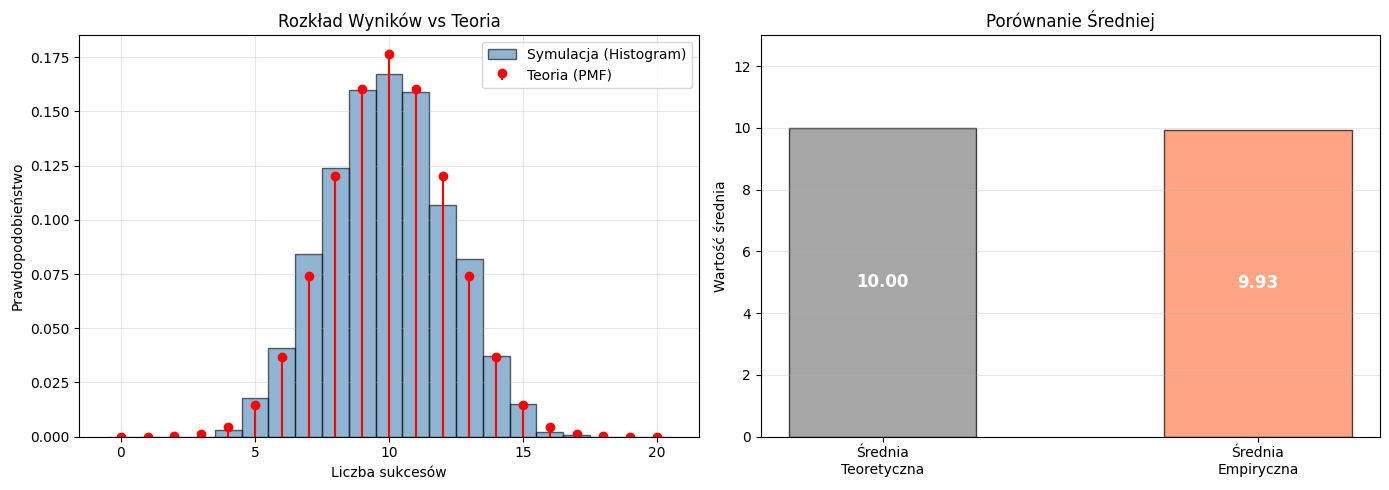

In [79]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# --- 1. PARAMETRY EKSPERYMENTU ---
n_trials = 20          # Liczba rzutu monet w jednej serii
p_success= 0.5         # Prawdopodobieństwo sukcesu (orła)
n_experiments = 1000   # Liczba symulacji eksperymentów
np.random.seed(42)     # Zastosowanie powtarzalności wyników

# --- 2. SYMULACJA DANYCH ---
# Każdy wynik to liczba sukcesów w 20 rzutach
simulation_results = np.random.binomial(n_trials, p_success, n_experiments)

# --- 3. STATYSTYKI OPISOWE ---
mean_empirical = np.mean(simulation_results)
std_empirical = np.std(simulation_results)
mean_theoretical = n_trials * p_success
std_theoretical = np.sqrt(n_trials * p_success * (1 - p_success))

print("=" * 60)
print("SYMULACJA ROZKŁADU DWUMIANOWANEGO: B(20, 0.5)")
print("=" * 60)
print(f"Liczba eksperymwntów: {n_experiments}")
print(f"Liczba rzutów w serii: {n_trials}")
print("-" * 60)
print(f"ŚREDNIA:")
print(f"Teoretyczna: {mean_theoretical:.4f}")
print(f"Empiryczna: {mean_empirical:.4f}")
print(f"Rónica: {abs(mean_theoretical - mean_empirical):.4f}")
print(f"\nODCHYLENIE STANDARDOWE:")
print(f"Teoretyczne: {std_theoretical:.4f}")
print(f"Empiryczne: {std_empirical:.4f}")
print("="*60)

# --- 4. TEST DOBRZESTNOŚCI DOPASOWANIA (Goodness of Fit) ---
# Sprawdzamy, czy dane z symulacji pasują do rozkładu teoretycznego
# H0: Dane pochodzą z rozkładu B(20, 0.5)
# H1: Dane NIE pochodzą z tego rozkładu

# Przygotowanie częstości obserwowanych i oczekiwanych
all_possible_k = np.arange(0, n_trials + 1)
observed_counts = pd.Series(simulation_results).value_counts().reindex(all_possible_k, fill_value=0).values
expected_counts = stats.binom.pmf(all_possible_k, n_trials, p_success) * n_experiments

# Zastosowanie maski
mask = expected_counts >= 5
f_obs = observed_counts[mask]
f_exp = expected_counts[mask]

# Skalowanie f_exp, aby suma f_obs == suma f_exp
# Jest to konieczne, ponieważ usunęliśmy skrajne wartości (ogon rozkładu)
f_exp = f_exp * (f_obs.sum() / f_exp.sum())

# Wykonanie testu
chi2_stat, p_val = stats.chisquare(f_obs, f_exp)

print(f"TEST CHI-KWADRAT (Goodness of Fit):")
print(f"  Suma obserwowana: {f_obs.sum()}")
print(f"  Suma oczekiwana:  {f_exp.sum():.1f}")
print(f"  p-value:          {p_val:.6f}")

if p_val < 0.05:
    print("WNIOSEK: Odrzucamy H0 - symulacja odbiega od teorii.")
else:
    print("WNIOSEK: Nie ma podstaw do odrzucenia H0 - symulacja zgodna z teorią.")
print("="*60)

# --- 5. WIZUALIZACJA ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lewy wykres: Histogram i Teoretyczny PMF
ax1 = axes[0]
ax1.hist(simulation_results, bins=np.arange(n_trials + 2) - 0.5, density=True, alpha=0.6, color='steelblue', edgecolor='black', label='Symulacja (Histogram)')
x = np.arange(0, n_trials + 1)
ax1.stem(x, stats.binom.pmf(x, n_trials, p_success), linefmt='red', markerfmt='ro', basefmt=" ", label='Teoria (PMF)')
ax1.set_title('Rozkład Wyników vs Teoria')
ax1.set_xlabel('Liczba sukcesów')
ax1.set_ylabel('Prawdopodobieństwo')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Prawy wykres: Porównanie Średnich (Bar chart)
ax2 = axes[1]
means = [mean_theoretical, mean_empirical]
labels = ['Średnia\nTeoretyczna', 'Średnia\nEmpiryczna']
bars = ax2.bar(labels, means, color=['gray', 'coral'], alpha=0.7, edgecolor='black', width=0.5)

# Dodanie wartości na słupkach
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height/2, f'{height:.2f}', ha='center', va='center', fontsize=12, fontweight='bold', color='white')

ax2.set_title('Porównanie Średniej')
ax2.set_ylim(0, n_trials/2 * 1.3)
ax2.set_ylabel('Wartość średnia')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


Zadanie 10 – Wykrywanie outliers metodą z-score
Dla datasetu Wine Quality zidentyfikuj outliery w kolumnie alcohol metodą z-score
(wartości > mean ± 3*std). Usuń outliery i porównaj statystyki przed/po.
Dataset:
- Wine Quality
Wymagania:
- Oblicz z-scores
- Zidentyfikuj outliery (|z| > 3)
- Boxplot przed i po usunięciu
- Porównanie statystyk (mean, median, std)

ANALIZA OUTLIERS METODĄ Z-SCORE (Kolumna: Alcohol)
Liczba wykrytych outlierów: 8
Wartości outlierów: [14.  14.  14.  14.  14.9 14.  14.  14. ]

STATYSTYKI DLA: PRZED CZYSZCZENIEM
  Shapiro-Wilk p-value: 0.000000
  Skewness (Skośność):  0.8608

STATYSTYKI DLA: PO CZYSZCZENIU
  Shapiro-Wilk p-value: 0.000000
  Skewness (Skośność):  0.7644

PORÓWNANIE STATYSTYK:
        Przed usunięciem  Po usunięciu
mean           10.422983     10.404431
median         10.200000     10.100000
std             1.065668      1.035413


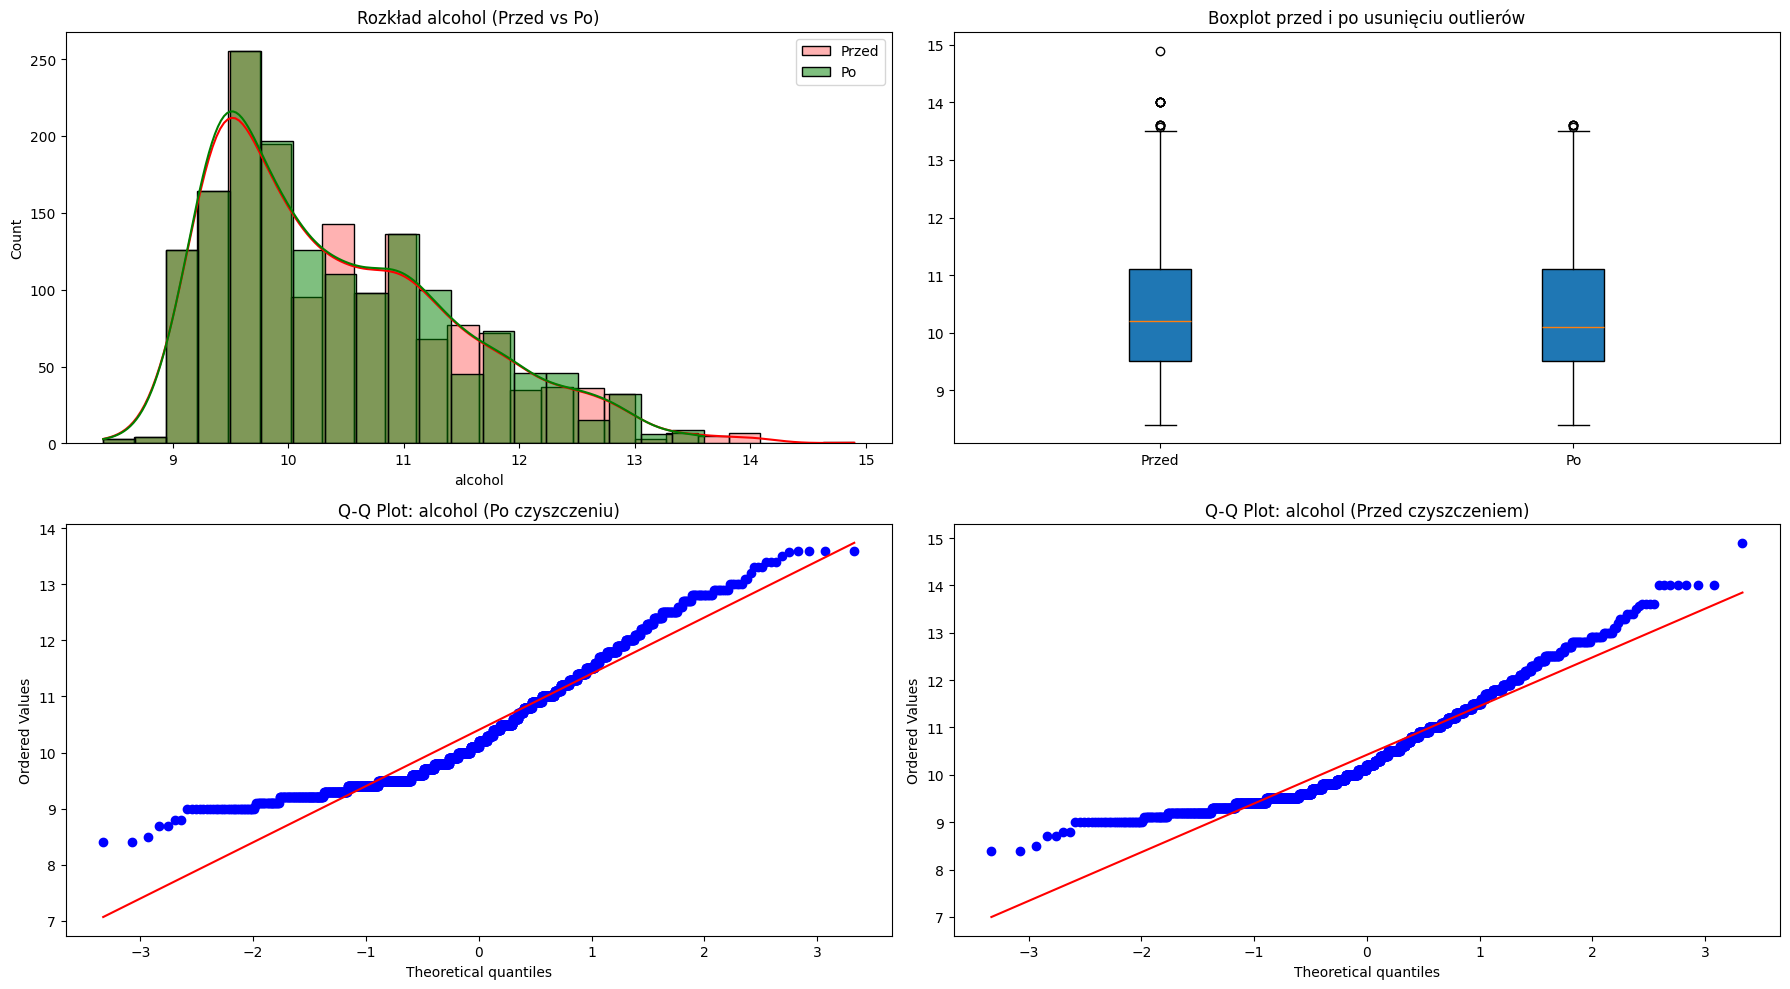

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. PRZYGOTOWANIE DANYCH
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
wine = pd.read_csv(url, sep=';')
variable = 'alcohol'

# 2. IDENTYFIKACJA OUTLIERÓW METODĄ Z-SCORE
data_raw = wine[variable]
z_scores = stats.zscore(data_raw)
abs_z_scores = np.abs(z_scores)

# Zgodnie z wymaganiem: wartości > mean ± 3*std
outliers_mask = abs_z_scores > 3
outliers_values = data_raw[outliers_mask].values
num_outliers = len(outliers_values)

# 3. CZYSZCZENIE DANYCH
wine_cleaned = wine[~outliers_mask]
data_clean = wine_cleaned[variable]

# 4. DIAGNOSTYKA STATYSTYCZNA (PRZED I PO)
stat_raw, p_raw = stats.shapiro(data_raw)
stat_clean, p_clean = stats.shapiro(data_clean)

# 5. GENEROWANIE RAPORTU TEKSTOWEGO
print("="*92)
print(f"ANALIZA OUTLIERS METODĄ Z-SCORE (Kolumna: {variable.capitalize()})")
print("="*92)
print(f"Liczba wykrytych outlierów: {num_outliers}")
print(f"Wartości outlierów: {outliers_values}")

print(f"\nSTATYSTYKI DLA: PRZED CZYSZCZENIEM")
print(f"  Shapiro-Wilk p-value: {p_raw:.6f}")
print(f"  Skewness (Skośność):  {data_raw.skew():.4f}")

print(f"\nSTATYSTYKI DLA: PO CZYSZCZENIU")
print(f"  Shapiro-Wilk p-value: {p_clean:.6f}")
print(f"  Skewness (Skośność):  {data_clean.skew():.4f}")

# Tabela porównawcza (mean, median, std)
comparison = pd.DataFrame({
    'Przed usunięciem': [data_raw.mean(), data_raw.median(), data_raw.std()],
    'Po usunięciu': [data_clean.mean(), data_clean.median(), data_clean.std()]
}, index=['mean', 'median', 'std'])

print("\nPORÓWNANIE STATYSTYK:")
print(comparison)
print("="*92)

# 6. WIZUALIZACJA (Histogram, Boxploty, Q-Q Plots)
plt.figure(figsize=(18, 10))

# Histogram porównawczy
plt.subplot(2, 2, 1)
sns.histplot(data_raw, kde=True, color='red', label='Przed', alpha=0.3)
sns.histplot(data_clean, kde=True, color='green', label='Po', alpha=0.5)
plt.title(f'Rozkład {variable} (Przed vs Po)')
plt.legend()

# Boxploty porównawcze
plt.subplot(2, 2, 2)
plt.boxplot([data_raw, data_clean], tick_labels=['Przed', 'Po'], patch_artist=True)
plt.title(f'Boxplot przed i po usunięciu outlierów')

# Wykres Q-Q po usunięciu
plt.subplot(2, 2, 3)
stats.probplot(data_clean, dist="norm", plot=plt)
plt.title(f'Q-Q Plot: {variable} (Po czyszczeniu)')

# Wykres Q-Q przed
plt.subplot(2, 2, 4)
stats.probplot(data_raw, dist="norm", plot=plt)
plt.title(f'Q-Q Plot: {variable} (Przed czyszczeniem)')

plt.tight_layout()
plt.show()